In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from numba import cuda

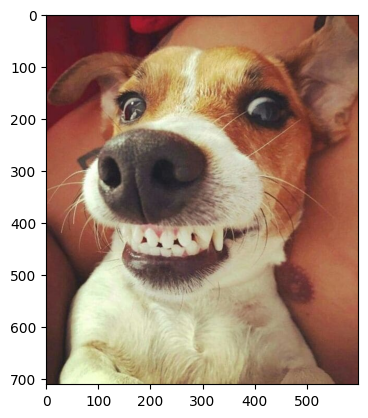

In [3]:
img = plt.imread("/content/dog.jpg")

plt.imshow(img)

In [10]:
height, width, channels = img.shape
pixelCount = height*width

In [11]:
devSrc = cuda.to_device(img)
devGray = cuda.device_array((height, width), dtype=np.uint8)
devDst = cuda.device_array((height, width), dtype=np.uint8)

In [12]:
blockSize = (32, 32)
gridSize = (math.ceil(width / blockSize[0]), math.ceil(height / blockSize[1]))

In [13]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
  dst[tidy, tidx] = g

In [26]:
grayscale[gridSize, blockSize](devSrc, devGray)
cuda.synchronize()

gray_gpu = devGray.copy_to_host()

Text(0.5, 1.0, 'GPU gray')

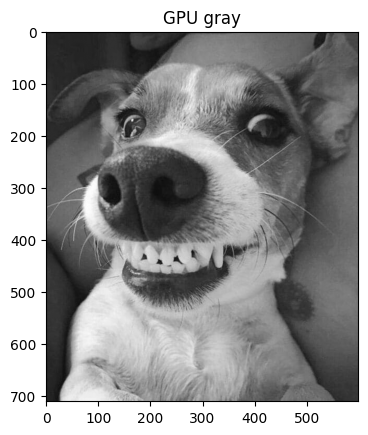

In [27]:
gp_image = gray_gpu.reshape(height, width)
plt.imshow(gp_image, cmap="gray")
plt.title("GPU gray")

In [17]:
devGray1D = devGray.reshape(pixelCount)

reduceBlockSize = 256
reduceGridSize = math.ceil(pixelCount / reduceBlockSize)

devMin = cuda.device_array(reduceGridSize, dtype=np.uint8)
devMax = cuda.device_array(reduceGridSize, dtype=np.uint8)

In [36]:
@cuda.jit
def reduce(src, block_min, block_max):
    min_cache = cuda.shared.array(shape=256, dtype=np.uint8)
    max_cache = cuda.shared.array(shape=256, dtype=np.uint8)

    localtid = cuda.threadIdx.x
    tid = cuda.blockIdx.x * cuda.blockDim.x + localtid

    s = int(cuda.blockDim.x / 2)
    while s > 0:
        if localtid < s:
            if min_cache[localtid + s] < min_cache[localtid]:
                min_cache[localtid] = min_cache[localtid + s]

            if max_cache[localtid + s] > max_cache[localtid]:
                max_cache[localtid] = max_cache[localtid + s]
        cuda.syncthreads()
        s = int(s / 2)

    if localtid == 0:
        block_min[cuda.blockIdx.x] = min_cache[0]
        block_max[cuda.blockIdx.x] = max_cache[0]


In [37]:
reduce[reduceGridSize, reduceBlockSize](devGray1D, devMin,devMax)
cuda.synchronize()

block_min = devMin.copy_to_host()
block_max = devMax.copy_to_host()
gray_min = int(np.min(block_min))
gray_max = int(np.max(block_max))
print("Minimum grayscale intensity:", gray_min)
print("Maximum grayscale intensity:", gray_max)

Minimum grayscale intensity: 15
Maximum grayscale intensity: 253


In [38]:
@cuda.jit
def stretch(src, dst, min, max):
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x

  g = src[tidy, tidx]
  dst[tidy, tidx] = int(((g - min) / (max - min)) * 255)

In [39]:
stretch[gridSize, blockSize](devGray, devDst, gray_min, gray_max)
cuda.synchronize()

str = devDst.copy_to_host()

Text(0.5, 1.0, 'Stretch gray')

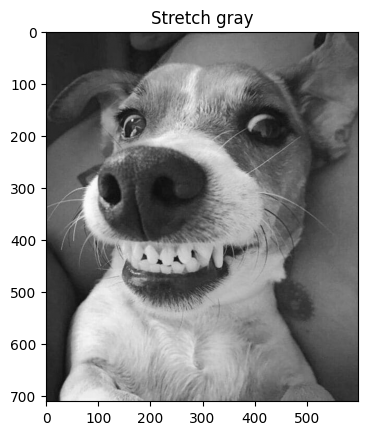

In [40]:
str_img = str.reshape(height, width)
plt.imshow(str_img, cmap="gray")
plt.title("Stretch gray")

In [42]:
block_2d = [(8, 4), (16, 4), (8, 16), (16, 16), (32, 16), (32, 32)]
gpu_times = []

for block in block_2d:
    block_x = block[0]
    block_y = block[1]
    blockSize_2D = (block_x, block_y)
    gridSize_2D = (math.ceil(width / block_x), math.ceil(height / block_y))

    start = time.time()
    grayscale[gridSize_2D, blockSize_2D](devSrc, devGray)
    reduce[reduceGridSize, reduceBlockSize](devGray1D, devMin, devMax)
    stretch[gridSize_2D, blockSize_2D](devGray, devDst, gray_min, gray_max)
    cuda.synchronize()
    gpu_time = time.time() - start

    gpu_times.append(gpu_time)

    print(f"Block size: {block_x} x {block_y}")
    print(f"Grid size: {gridSize_2D}")
    print(f"Threads per block: {block_x * block_y}")
    print(f"GPU time: {gpu_time:.6f} seconds")
    print()


Block size: 8 x 4
Grid size: (75, 178)
Threads per block: 32
GPU time: 0.001390 seconds

Block size: 16 x 4
Grid size: (38, 178)
Threads per block: 64
GPU time: 0.000651 seconds

Block size: 8 x 16
Grid size: (75, 45)
Threads per block: 128
GPU time: 0.000630 seconds

Block size: 16 x 16
Grid size: (38, 45)
Threads per block: 256
GPU time: 0.000633 seconds

Block size: 32 x 16
Grid size: (19, 45)
Threads per block: 512
GPU time: 0.000842 seconds

Block size: 32 x 32
Grid size: (19, 23)
Threads per block: 1024
GPU time: 0.000643 seconds

